# Project-1 | Unsupervised Learning

## CAR MPG

In [76]:
from __future__ import print_function

#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn import metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LinearRegression

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc


from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import fcluster


In [3]:
car_df=pd.read_csv("cars-dataset.csv")

In [4]:
car_df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [6]:
car_df.shape

(398, 8)

In [7]:
car_df.describe()

,cyl,disp,wt,acc,yr,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,2970.424623,15.568090,76.010050,23.514573
std,1.701004,104.269838,846.841774,2.757689,3.697627,7.815984
min,3.000000,68.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,104.250000,2223.750000,13.825000,73.000000,17.500000
50%,4.000000,148.500000,2803.500000,15.500000,76.000000,23.000000
75%,8.000000,262.000000,3608.000000,17.175000,79.000000,29.000000
max,8.000000,455.000000,5140.000000,24.800000,82.000000,46.600000


In [10]:
car_df.dtypes

car name     object
cyl           int64
disp        float64
hp           object
wt            int64
acc         float64
yr            int64
mpg         float64
dtype: object

In [14]:
car_df.loc[car_df['hp']=='?',:]

,car name,cyl,disp,hp,wt,acc,yr,mpg
32,ford pinto,4,98.0,?,2046,19.0,71,25.0
126,ford maverick,6,200.0,?,2875,17.0,74,21.0
330,renault lecar deluxe,4,85.0,?,1835,17.3,80,40.9
336,ford mustang cobra,4,140.0,?,2905,14.3,80,23.6
354,renault 18i,4,100.0,?,2320,15.8,81,34.5
374,amc concord dl,4,151.0,?,3035,20.5,82,23.0


In [16]:
car_df['hp'] = car_df['hp'].replace({'?': 0})

In [17]:
car_df['hp'] = pd.to_numeric(car_df['hp'])

In [18]:
car_df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [19]:
car_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
hp,398.0,102.894472,40.269544,0.0,75.000,92.0,125.000,230.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [24]:
car_df['hp'] = car_df['hp'].replace({0: 92})

In [25]:
car_df=car_df.set_index('car name')

KeyError: 'car name'

In [26]:
car_df.head()

,cyl,disp,hp,wt,acc,yr,mpg
car name,,,,,,,
chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
buick skylark 320,8,350.0,165,3693,11.5,70,15.0
plymouth satellite,8,318.0,150,3436,11.0,70,18.0
amc rebel sst,8,304.0,150,3433,12.0,70,16.0
ford torino,8,302.0,140,3449,10.5,70,17.0


In [27]:
car_df.describe()

,cyl,disp,hp,wt,acc,yr,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.281407,2970.424623,15.568090,76.010050,23.514573
std,1.701004,104.269838,38.229470,846.841774,2.757689,3.697627,7.815984
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,17.500000
50%,4.000000,148.500000,92.000000,2803.500000,15.500000,76.000000,23.000000
75%,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,29.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,46.600000


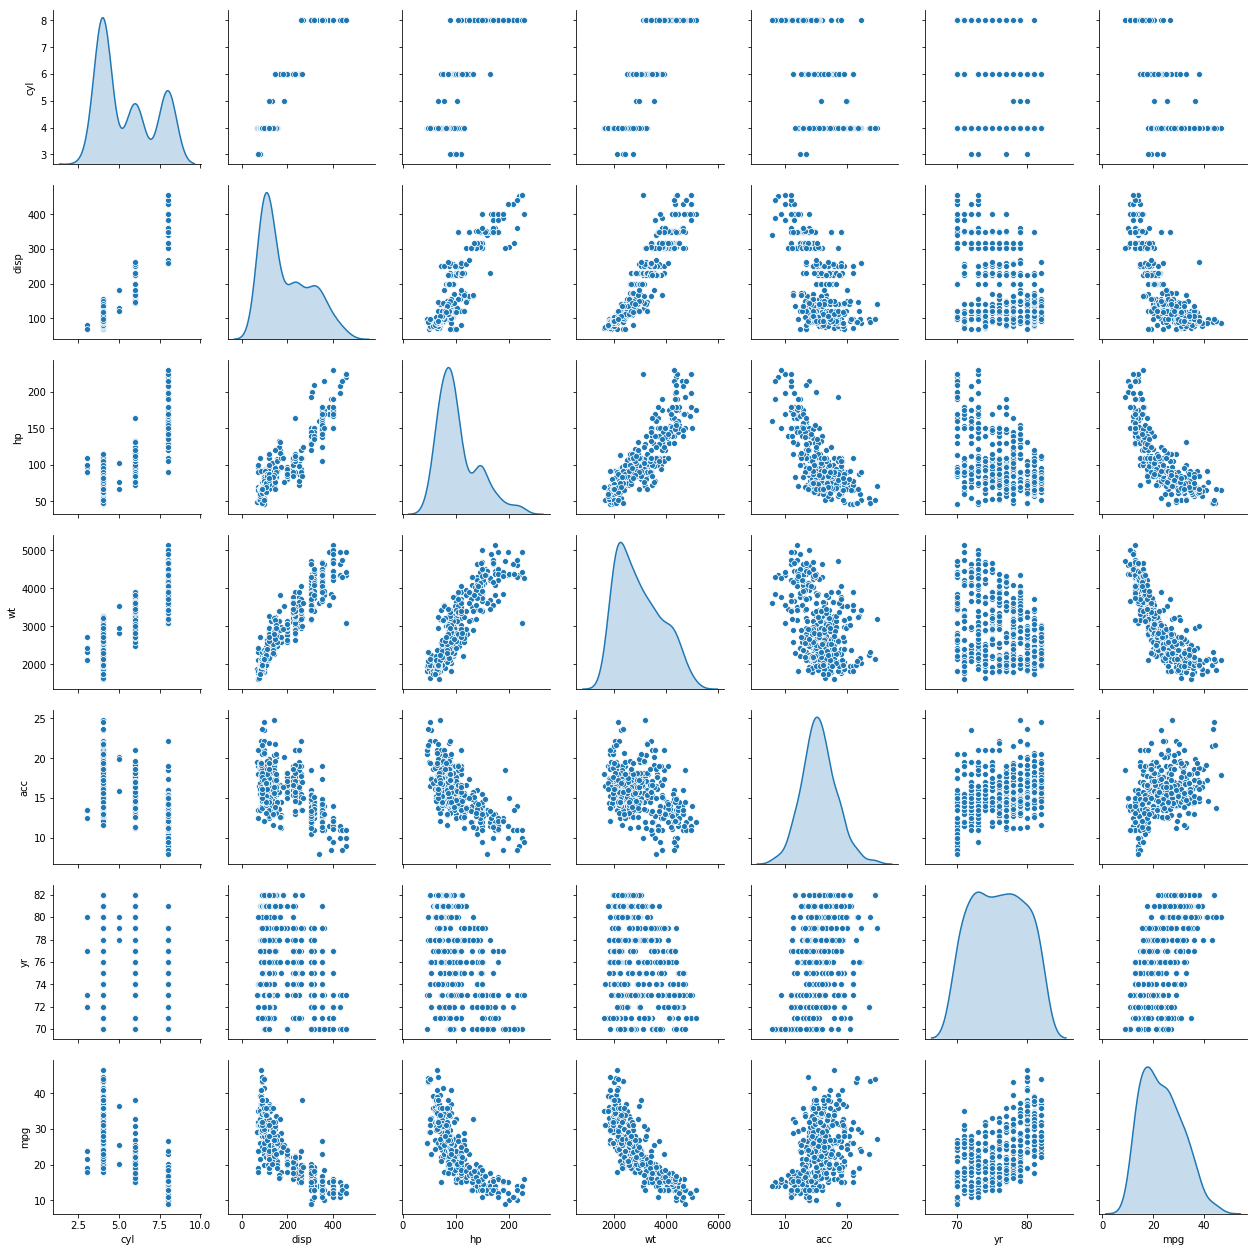

In [29]:
# Pairplot using sns -   bivariate analysis
sns.pairplot(car_df, diag_kind='kde')

### Optimal clusterts from Kmeans

In [32]:
distortion=[]

In [33]:

clusters=range(2,20)
cluster_errors = []


for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(car_df)
    prediction=model.predict(car_df)
    distortion.append(sum(np.min(cdist(car_df, model.cluster_centers_, 'euclidean'), axis=1)) / car_df.shape[0])
    cluster_errors.append( model.inertia_ )
    
clusters_df = pd.DataFrame( { "num_clusters":clusters, "cluster_errors": cluster_errors } )
cluster_errors

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=2, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=5, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=6, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

...

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=16, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=17, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=18, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=19, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

[74289230.0774004,
 34207964.76594871,
 19051457.465107642,
 13765965.64463704,
 10297892.048959505,
 7663411.734283216,
 5663601.407976534,
 4729811.121205274,
 4043678.7524543433,
 3325629.1038773325,
 2902794.189996355,
 2588593.343041365,
 2199729.187826234,
 1960301.9964265006,
 1793692.9165370597,
 1662460.9258364243,
 1544221.7419229387,
 1464111.655065949]

In [34]:
clusters_df

,num_clusters,cluster_errors
0,2,7.428923e+07
1,3,3.420796e+07
2,4,1.905146e+07
3,5,1.376597e+07
4,6,1.029789e+07
5,7,7.663412e+06
6,8,5.663601e+06
7,9,4.729811e+06
8,10,4.043679e+06
9,11,3.325629e+06


Text(0.5, 0, 'k')

Text(0, 0.5, 'Average distortion')

Text(0.5, 1.0, 'Selecting k with the Elbow Method')

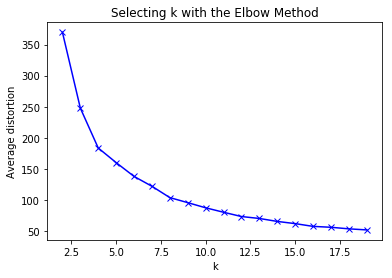

In [37]:
plt.show(20,20)
plt.plot(clusters, distortion, 'bx-')
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')

### Optimal clusters from dendogram

In [39]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist  #Pairwise distribution between data points

In [43]:
Z = linkage(car_df, 'ward',metric='euclidean')
c, coph_dists = cophenet(Z , pdist(car_df))

Z

array([[1.80000000e+01, 2.90000000e+01, 1.00000000e+00, 2.00000000e+00],
       [1.81000000e+02, 1.98000000e+02, 1.00498756e+00, 2.00000000e+00],
       [1.75000000e+02, 1.97000000e+02, 1.01980390e+00, 2.00000000e+00],
       ...,
       [7.88000000e+02, 7.90000000e+02, 6.32546309e+03, 1.32000000e+02],
       [7.89000000e+02, 7.91000000e+02, 8.58074618e+03, 2.66000000e+02],
       [7.92000000e+02, 7.93000000e+02, 2.06267527e+04, 3.98000000e+02]])

<Figure size 720x720 with 0 Axes>

Text(0.5, 1.0, 'Agglomerative Hierarchical Clustering Dendogram')

Text(0.5, 0, 'sample index')

Text(0, 0.5, 'Distance')

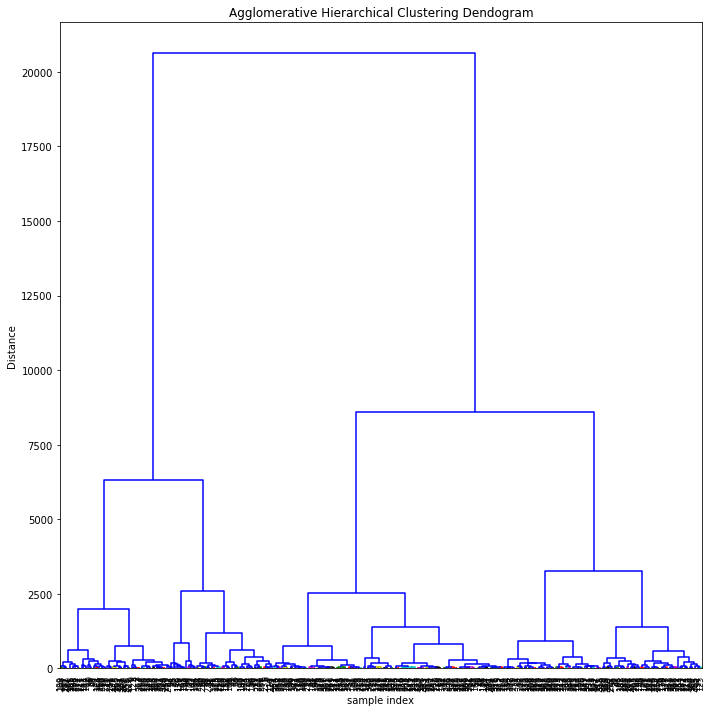

In [44]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
den1=dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

<Figure size 720x720 with 0 Axes>

Text(0.5, 1.0, 'Agglomerative Hierarchical Clustering Dendogram')

Text(0.5, 0, 'sample index')

Text(0, 0.5, 'Distance')

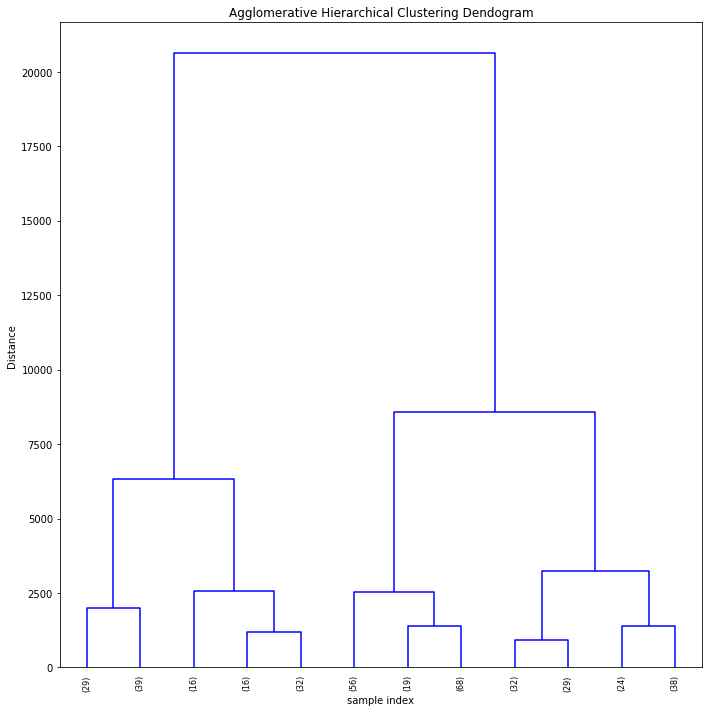

In [45]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
den1=dendrogram(Z, leaf_rotation=90.,color_threshold = 60, leaf_font_size=8.,truncate_mode='lastp',p=12 )
plt.tight_layout()

#### 4 clusters seems to be optimal even from dendogram

### Using 

Automatically created module for IPython interactive environment


(-0.1, 1)

(0, 448)

For n_clusters = 4 The average silhouette_score is : 0.5792168298984415


Text(-0.05, 44.5, '0')

...

[]

Text(0.5, 1.0, 'The visualization of the clustered data.')

Text(0.5, 0, 'Feature space for the 1st feature')

Text(0, 0.5, 'Feature space for the 2nd feature')

Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 4')

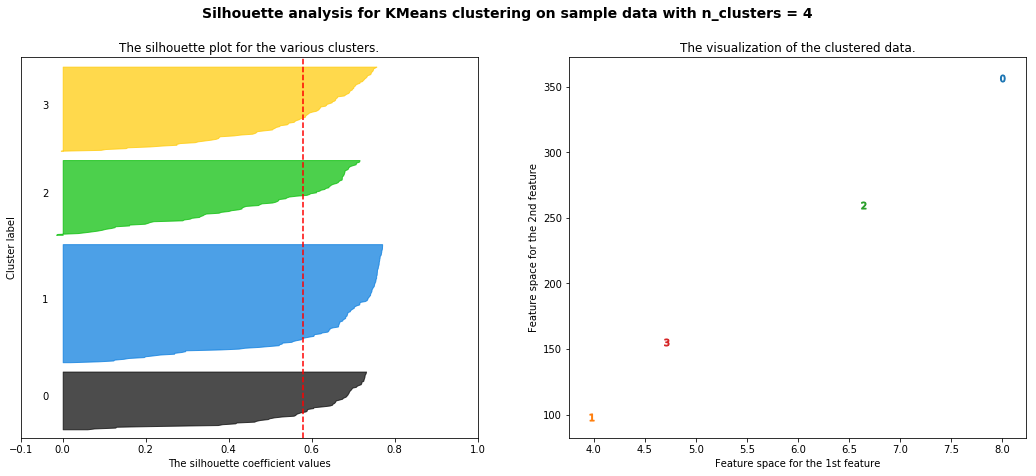

(-0.1, 1)

(0, 458)

For n_clusters = 5 The average silhouette_score is : 0.5554380710559854


Text(-0.05, 79.5, '0')

Text(-0.05, 185.0, '1')

...

[]

Text(0.5, 1.0, 'The visualization of the clustered data.')

Text(0.5, 0, 'Feature space for the 1st feature')

Text(0, 0.5, 'Feature space for the 2nd feature')

Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 5')

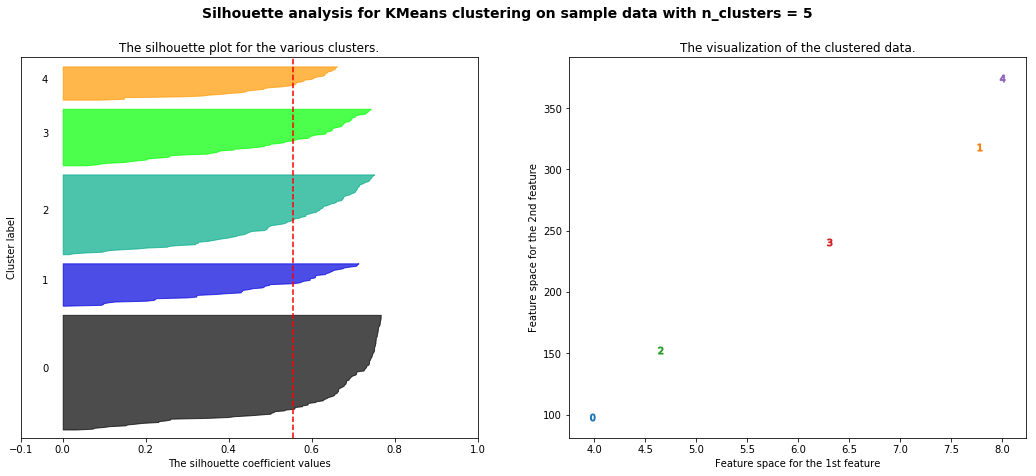

(-0.1, 1)

(0, 468)

For n_clusters = 6 The average silhouette_score is : 0.522595313043077


Text(-0.05, 38.0, '0')

Text(-0.05, 96.5, '1')

...

[]

Text(0.5, 1.0, 'The visualization of the clustered data.')

Text(0.5, 0, 'Feature space for the 1st feature')

Text(0, 0.5, 'Feature space for the 2nd feature')

Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 6')

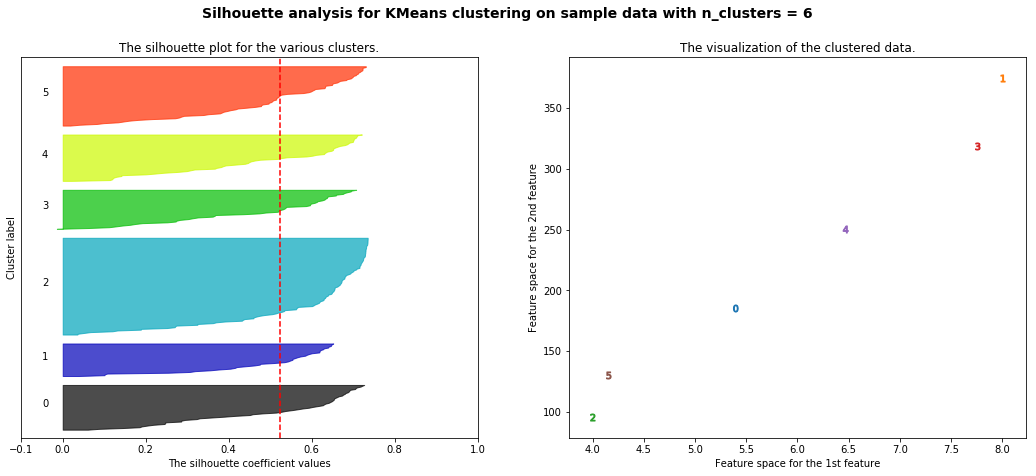

(-0.1, 1)

(0, 478)

For n_clusters = 7 The average silhouette_score is : 0.5035886174118701


Text(-0.05, 45.5, '0')

Text(-0.05, 120.0, '1')

...

[]

Text(0.5, 1.0, 'The visualization of the clustered data.')

Text(0.5, 0, 'Feature space for the 1st feature')

Text(0, 0.5, 'Feature space for the 2nd feature')

Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 7')

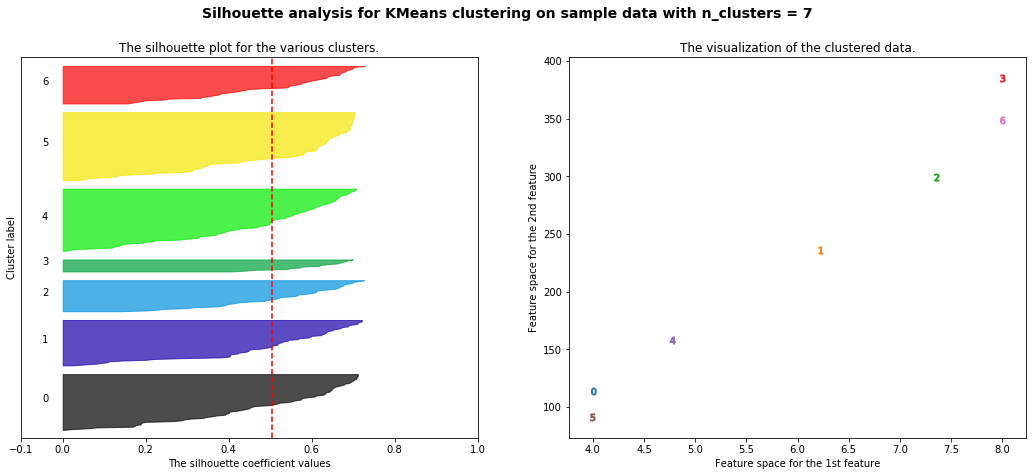

(-0.1, 1)

(0, 488)

For n_clusters = 8 The average silhouette_score is : 0.5212073127240706


Text(-0.05, 34.0, '0')

Text(-0.05, 107.5, '1')

...

[]

Text(0.5, 1.0, 'The visualization of the clustered data.')

Text(0.5, 0, 'Feature space for the 1st feature')

Text(0, 0.5, 'Feature space for the 2nd feature')

Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 8')

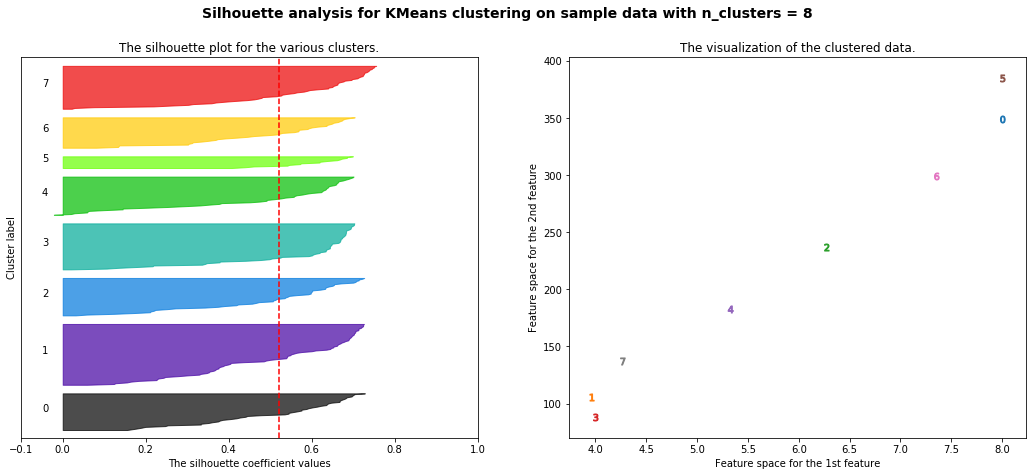

In [56]:


from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print(__doc__)

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.a

range_n_clusters = [ 4, 5, 6,7,8]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(car_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(car_df)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(car_df, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(car_df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
#    ax2.scatter(car_df[:, 0], car_df[:, 1], marker='.', s=30, lw=0, alpha=0.7,c=colors)

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1],
                marker='o', c="white", alpha=1, s=200)

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50)

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

    plt.show()

### Optimal clusters 4 confirmed by - elbow method, dendogram & silhouette analysis

In [50]:

model=KMeans(n_clusters=4)
model.fit(car_df)
prediction=model.predict(car_df)
distortion.append(sum(np.min(cdist(car_df, model.cluster_centers_, 'euclidean'), axis=1)) / car_df.shape[0])
cluster_errors.append( model.inertia_ )
cluster_errors

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

[74289230.0774004,
 34207964.76594871,
 19051457.465107642,
 13765965.64463704,
 10297892.048959505,
 7663411.734283216,
 5663601.407976534,
 4729811.121205274,
 4043678.7524543433,
 3325629.1038773325,
 2902794.189996355,
 2588593.343041365,
 2199729.187826234,
 1960301.9964265006,
 1793692.9165370597,
 1662460.9258364243,
 1544221.7419229387,
 1464111.655065949,
 19056551.703906484]

In [64]:
car_df1=car_df
car_df1['cluster']=prediction
car_df1.head()

,cyl,disp,hp,wt,acc,yr,mpg,cluster
car name,,,,,,,,
chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0,1
buick skylark 320,8,350.0,165,3693,11.5,70,15.0,1
plymouth satellite,8,318.0,150,3436,11.0,70,18.0,1
amc rebel sst,8,304.0,150,3433,12.0,70,16.0,1
ford torino,8,302.0,140,3449,10.5,70,17.0,1


In [65]:
car_df1['cluster'].value_counts()

0    140
2    100
1     89
3     69
Name: cluster, dtype: int64

### Linear Regression on each cluster

In [102]:
for i in range(0,4):
    df=car_df1.loc[car_df1['cluster']==i,]
    df=df.drop("cluster",axis=1)
    X = df.drop("mpg", axis=1)
    y = df["mpg"]
    regression_model = LinearRegression()
    regression_model.fit(X, y)
    coef=pd.DataFrame({'variable':X.columns,'coefficient':regression_model.coef_})
    print("********** Clusters %d*********" % i)
    print("********** volume %d*********" % len(X))
    coef.sort_values(by='coefficient', ascending=False)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

********** Clusters 0*********
********** volume 140*********


,variable,coefficient
0,cyl,9.679714
5,yr,1.011621
4,acc,0.117199
2,hp,-0.002173
3,wt,-0.006088
1,disp,-0.075770


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

********** Clusters 1*********
********** volume 89*********


...

********** Clusters 2*********
********** volume 100*********


,variable,coefficient
5,yr,0.747032
0,cyl,0.295699
3,wt,-0.007039
1,disp,-0.011465
2,hp,-0.092815
4,acc,-0.273979


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

********** Clusters 3*********
********** volume 69*********


,variable,coefficient
5,yr,0.430828
0,cyl,0.000000
1,disp,-0.001437
3,wt,-0.001702
2,hp,-0.013188
4,acc,-0.370953


In [ ]:
)